#M1 - Environment Setup

In [1]:
!pip uninstall -y youtube-transcript-api
!pip install -q --upgrade youtube-transcript-api
!pip install -q langchain langchain-community langchain-text-splitters networkx beautifulsoup4 youtube-transcript-api sentence-transformers faiss-cpu openai tiktoken matplotlib

import os
import getpass
import json
import networkx as nx
import matplotlib.pyplot as plt
from google.colab import drive

print("Mounting Google Drive to save your Knowledge Graph...")
drive.mount('/content/drive')
SAVE_PATH = "/content/drive/My Drive/erica_graph_data"
os.makedirs(SAVE_PATH, exist_ok=True)

if "OPENROUTER_API_KEY" not in os.environ:
    os.environ["OPENROUTER_API_KEY"] = getpass.getpass("Enter your OpenRouter API Key: ")

from openai import OpenAI

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ["OPENROUTER_API_KEY"],
)

MODEL_NAME = "qwen/qwen-2.5-72b-instruct"

print("✅ Environment Ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.1/485.1 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 115.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
Mounting Google Drive to save your Knowledge Graph...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Enter your OpenRouter API Key: ··········
✅ Environment Ready.


#M2 - Ingestion

In [2]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
import requests
from bs4 import BeautifulSoup
from youtube_transcript_api import YouTubeTranscriptApi

URLS = [
    "https://pantelis.github.io/courses/ai/in-person.html",
    "https://pantelis.github.io/aiml-common/lectures/nlp/language-models/rnn-language-model/",
    "https://pantelis.github.io/aiml-common/lectures/nlp/nlp-introduction/nlp-pipelines/"
]

VIDEO_ID = "Qw0Bdsa_3Yg"

raw_data = []

def scrape_web(url):
    print(f"Scraping: {url}")
    try:
        resp = requests.get(url)
        soup = BeautifulSoup(resp.content, 'html.parser')
        main_content = soup.find('main') or soup.find('article') or soup.body
        text = main_content.get_text(separator="\n", strip=True)
        return text
    except Exception as e:
        print(f"Error scraping {url}: {e}")
        return ""

def get_youtube_transcript(video_id):
    print(f"Fetching Transcript for Video ID: {video_id}")
    try:
        transcript_list_obj = YouTubeTranscriptApi.list_transcripts(video_id)
        transcript_data = transcript_list_obj.find_transcript(['en', 'en-US']).fetch()
        full_text = ""
        for entry in transcript_data:
            timestamp = int(entry['start'])
            text = entry['text']
            full_text += f"[{timestamp}s] {text}\n"
        return full_text
    except Exception as e:
        print(f"Error fetching transcript: {e}")
        return ""

for url in URLS:
    text = scrape_web(url)
    if text:
        raw_data.append({"source": url, "text": text, "type": "web"})

video_text = get_youtube_transcript(VIDEO_ID)
if video_text:
    video_url = f"https://www.youtube.com/watch?v={VIDEO_ID}"
    raw_data.append({"source": video_url, "text": video_text, "type": "video"})

print(f"\n✅ Ingestion Complete. Processed {len(raw_data)} sources.")
print("--- Ingested Sources ---")
for item in raw_data:
    print(f"- {item['type'].upper()}: {item['source']} ({len(item['text'])} chars)")

Scraping: https://pantelis.github.io/courses/ai/in-person.html
Scraping: https://pantelis.github.io/aiml-common/lectures/nlp/language-models/rnn-language-model/
Scraping: https://pantelis.github.io/aiml-common/lectures/nlp/nlp-introduction/nlp-pipelines/
Fetching Transcript for Video ID: Qw0Bdsa_3Yg
Error fetching transcript: type object 'YouTubeTranscriptApi' has no attribute 'list_transcripts'

✅ Ingestion Complete. Processed 3 sources.
--- Ingested Sources ---
- WEB: https://pantelis.github.io/courses/ai/in-person.html (1940 chars)
- WEB: https://pantelis.github.io/aiml-common/lectures/nlp/language-models/rnn-language-model/ (3138 chars)
- WEB: https://pantelis.github.io/aiml-common/lectures/nlp/nlp-introduction/nlp-pipelines/ (4157 chars)


#M3 - GraphRAG Construction

Created 6 chunks for processing.
Building Graph (This may take time)...
Processing chunk 1/6...
LLM Error: Expecting value: line 1 column 1 (char 0)
Processing chunk 2/6...
Processing chunk 3/6...
Processing chunk 4/6...
Processing chunk 5/6...
Processing chunk 6/6...
LLM Error: Expecting value: line 1 column 1 (char 0)
✅ Graph constructed with 32 nodes and 51 edges.
Graph saved to /content/drive/My Drive/erica_graph_data/erica_graph.gpickle


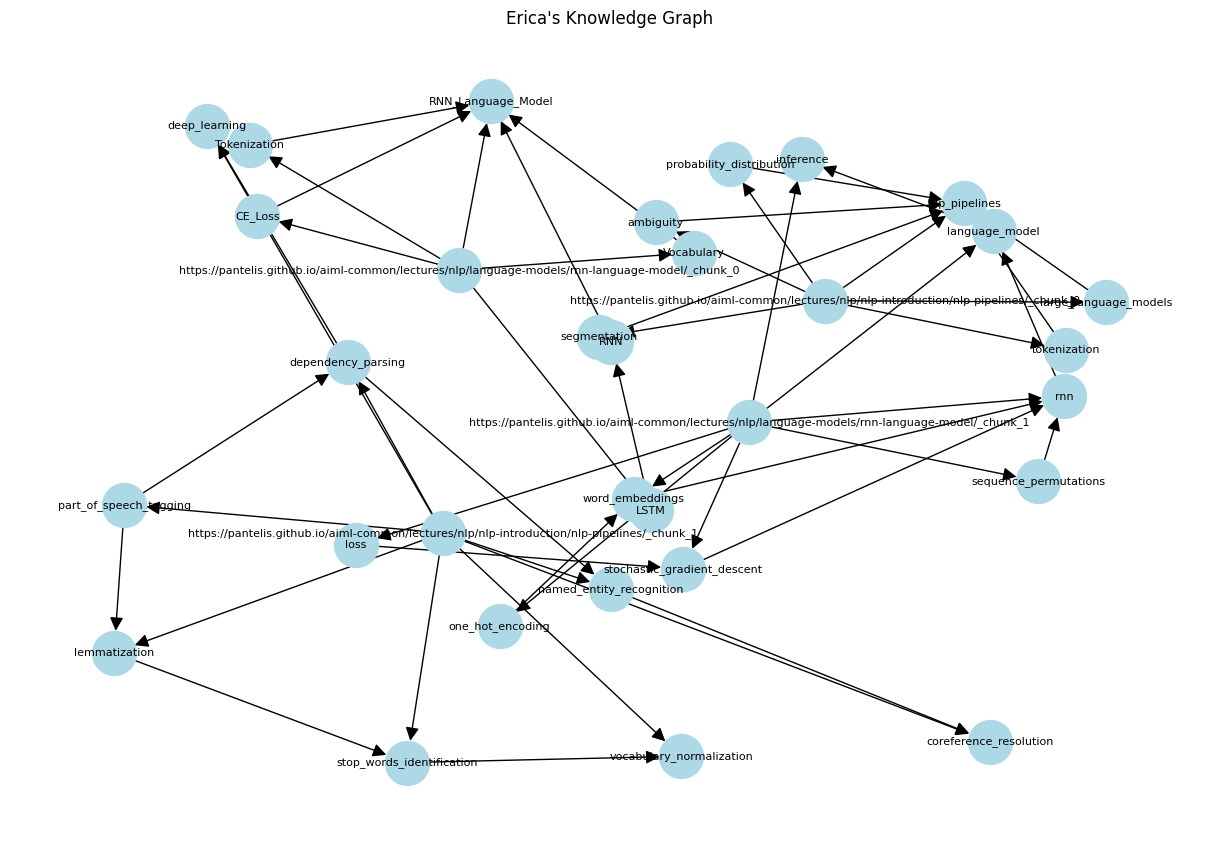

In [3]:
import pickle
import time

text_splitter = RecursiveCharacterTextSplitter(chunk_size=2000, chunk_overlap=200)
chunks = []

for entry in raw_data:
    split_texts = text_splitter.split_text(entry['text'])
    for i, text in enumerate(split_texts):
        chunks.append({
            "chunk_id": f"{entry['source']}_chunk_{i}",
            "source": entry['source'],
            "text": text
        })

print(f"Created {len(chunks)} chunks for processing.")

G = nx.DiGraph()

def extract_graph_elements(chunk_text, source):
    system_prompt = """
    You are an AI expert building a Knowledge Graph for a course. Your goal is to extract structured knowledge from the provided text.

    Extract the following strictly as JSON:
    1. "concepts": List of objects { "id": "concept_name", "title": "Display Title", "difficulty": "basic/intermediate/advanced", "summary": "brief definition" }
    2. "edges": List of objects { "source": "concept_id_A", "target": "concept_id_B", "relation": "relation_type" }
       - relation_type must be one of: "prereq_of", "near_transfer", "part_of", "is_a"
    3. "resources": List of objects { "concept_id": "concept_id", "description": "context from text" }

    Ignore generic terms. Focus on AI/ML technical terms (e.g., "RNN", "Gradient Descent", "Tokenization").
    """

    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": f"Source: {source}\n\nText:\n{chunk_text}"}
            ],
            response_format={"type": "json_object"}
        )
        return json.loads(response.choices[0].message.content)
    except Exception as e:
        print(f"LLM Error: {e}")
        return None

print("Building Graph (This may take time)...")

for i, chunk in enumerate(chunks[:8]):
    print(f"Processing chunk {i+1}/{len(chunks[:8])}...")
    data = extract_graph_elements(chunk['text'], chunk['source'])

    if data:
        for concept in data.get("concepts", []):
            G.add_node(concept['id'], type='concept', **concept)

        for edge in data.get("edges", []):
            if G.has_node(edge['source']) and G.has_node(edge['target']):
                G.add_edge(edge['source'], edge['target'], relation=edge['relation'])

        resource_id = chunk['chunk_id']
        G.add_node(resource_id, type='resource', source=chunk['source'], text=chunk['text'])

        for res in data.get("resources", []):
            if G.has_node(res['concept_id']):
                G.add_edge(resource_id, res['concept_id'], relation='explains')

    time.sleep(1)

graph_path = os.path.join(SAVE_PATH, "erica_graph.gpickle")
with open(graph_path, 'wb') as f:
    pickle.dump(G, f)

print(f"✅ Graph constructed with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")
print(f"Graph saved to {graph_path}")

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.5)
nx.draw(G, pos, with_labels=True, node_size=1000, font_size=8, node_color="lightblue", arrowsize=20)
plt.title("Erica's Knowledge Graph")
plt.show()

#M4 - Queries and Generation

In [4]:

def retrieve_subgraph_context(query, graph, depth=1):
    """
    Finds relevant nodes based on keyword matching and retrieves their neighborhood (subgraph).
    """
    query_terms = query.lower().split()
    relevant_nodes = []

    for node, data in graph.nodes(data=True):
        if data.get('type') == 'concept':
            if any(term in node.lower() for term in query_terms):
                relevant_nodes.append(node)

    if not relevant_nodes:
        return "No specific concepts found in Knowledge Graph."

    context_text = []
    visited_resources = set()

    for node in relevant_nodes:
        concept_data = graph.nodes[node]
        context_text.append(f"CONCEPT: {concept_data.get('title')} ({concept_data.get('summary')})")
        predecessors = graph.predecessors(node)
        for pred in predecessors:
            if graph.nodes[pred].get('type') == 'resource':
                if pred not in visited_resources:
                    src_doc = graph.nodes[pred]
                    snippet = src_doc['text'][:300] + "..."
                    context_text.append(f"SOURCE ({src_doc['source']}):\n{snippet}\n")
                    visited_resources.add(pred)
            elif graph.nodes[pred].get('type') == 'concept':
                 context_text.append(f"PREREQUISITE: {pred} is a prerequisite of {node}")

    return "\n".join(context_text)

def generate_answer(query):
    context = retrieve_subgraph_context(query, G)

    system_prompt = f"""
    You are Erica, an AI Tutor. Use the provided Knowledge Graph context to answer.

    Context:
    {context}

    Guidelines:
    - Start with simple concepts and build up.
    - If prerequisites are listed in context, mention them.
    - Cite the specific resources provided in the context.
    """

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": query}
        ]
    )

    print(f"❓ Q: {query}")
    print(f"💡 A: {response.choices[0].message.content}")
    print("-" * 50)

questions = [
    "What is attention in transformers and can you provide a python example of how it is used ?",
    "What is CLIP and how it is used in computer vision applications ?",
    "Can you explain the variational lower bound and how it relates to Jensen’s inequality ?"
]

for q in questions:
    generate_answer(q)

❓ Q: What is attention in transformers and can you provide a python example of how it is used ?
💡 A: The concept of attention in transformers is a crucial mechanism that allows the model to focus on specific parts of the input sequence when making predictions. This is particularly useful in handling long sequences, as it helps the model to maintain and utilize relevant information more effectively, addressing the limitations of traditional RNN-based models which suffer from the vanishing gradient problem and limited context window.

### Key Concepts of Attention in Transformers

1. **Query, Key, and Value Vectors**:
   - **Query (Q)**: Represents the current token or position in the sequence that the model is trying to predict or understand.
   - **Key (K)**: Represents the tokens in the sequence that the query can attend to.
   - **Value (V)**: Represents the actual information or content that the model will use from the attended tokens.

2. **Attention Mechanism**:
   - The attention